In [1]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")

from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math
import matplotlib.pyplot as plt


In [3]:
dms_input_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/tests/data/20241207_rluc_dms_input.csv")
Rluc_AA = 'MTSKVYDPEQRKRMITGPQWWARCKQMNVLDSFINYYDSEKHAENAVIFLHGNAASSYLWRHVVPHIEPVARCIIPDLIGMGKSGKSGNGSYRLLDHYKYLTAWFELLNLPKKIIFVGHDWGACLAFHYSYEHQDKIKAIVHAESVVDVIESWDEWPDIEEDIALIKSEEGEKMVLENNFFVETMLPSKIMRKLEPEEFAAYLEPFKEKGEVRRPTLSWPREIPLVKGGKPDVVQIVRNYNAYLRASDDLPKMFIESDPGFFSNAIVEGAKKFPNTEFVKVKGLHFSQEDAPDEMGKYIKSFVERVLKNEQ'

picked_mutants_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/notebooks/20250302_Rluc_prediction_processing/outputs/picked_mutants_df.csv")

# read in a parts list for the echo
echo_parts_df=pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/data/Rluc_parts_concentrations.csv").drop(columns = ["Unnamed: 4"])



# read in the mappings df
mid_mut_map_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/tests/data/assembly_parts/sequencing_df.csv")
mid_mut_map_df["length"] = mid_mut_map_df["full_plasmid"].str.len()
mid_mut_map_df = mid_mut_map_df[["m_id", "mut_str", "length"]]
mid_mut_map_df["type"] = "mut"

# add wildtype information and backbone information to the mapping df
wt_mut_str = ["M14M", "M27M", "M81M", "M174M", "M185M", "M191M", "M253M", "M295M"]
wt_mids = ["m214", "m215", "m216", "m218", "m219", "m220", "m221", "m222"]
wt_lens = [2210, 2250, 2324, 2191, 2145, 2286, 2197, 2205]

for mut, mid, length in zip(wt_mut_str, wt_mids, wt_lens):
    new_line = pd.DataFrame({"m_id": [mid],
                  "mut_str": [mut],
                  "length": [length],
                  "type":["wt"]})
    
    mid_mut_map_df = pd.concat([mid_mut_map_df, new_line], ignore_index=True)



mids = ["m211", "m212", "m217"]
lens = [8264, 8270, 2324]
types = ["bb", "bb", "mut"]
mut_list = [None, None, "E144Y"]

# add backbone information
for mid, length, mut_str, t in zip(mids, lens, mut_list, types) :
    new_line = pd.DataFrame({"m_id": [mid],
                  "mut_str": [mut_str],
                  "length": [length],
                  "type":[t]})
    
    mid_mut_map_df = pd.concat([mid_mut_map_df, new_line], ignore_index=True)

echo_parts_df = echo_parts_df.merge(mid_mut_map_df, on="m_id", how="left")

echo_parts_df["concentration (nM)"] = echo_parts_df["concentration (ng/uL)"] * 1000000/(650*echo_parts_df["length"])

echo_parts_df["MW (ng/fmol)"] = echo_parts_df["length"] * 0.65 /1000

Text(0.5, 1.0, 'nM concentrations of parts')

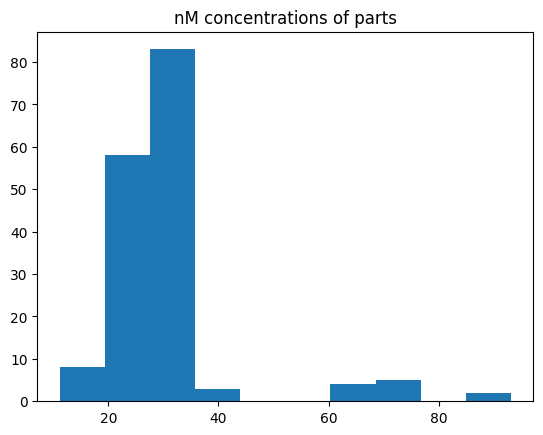

In [6]:
plt.hist(echo_parts_df["concentration (nM)"])
plt.title("nM concentrations of parts")

In [7]:
echo_parts_df[echo_parts_df.isna().any(axis=1)]

,plate,well,m_id,concentration (ng/uL),mut_str,length,type,concentration (nM),MW (ng/fmol)
161,3,B2,m211,500.0,None,8264,bb,93.082136,5.3716
162,3,B3,m212,500.0,None,8270,bb,93.014603,5.3755


In [8]:
# make a dictionary of mutants to mids of our parts
mut_map_dict = echo_parts_df[["m_id", "mut_str"]].set_index("mut_str")["m_id"].to_dict()
mut_map_dict.pop(None)
len(mut_map_dict)

161

In [9]:
# set the index to the m_id
echo_parts_df = echo_parts_df.set_index("m_id")

In [10]:
test_1 = ["M14L"]
test_2 = ["M14L", "M27L", "M81L", "M174L", "M185L", "M191L", "M253L", "M295L"]
test_3 = ["M14M", "M27M", "M81M", "M174M", "M185M", "M191M", "M253M", "M295M"]

positions_list = dms_input_df["position_1_idx"].unique().tolist()
positions_list

[14, 27, 81, 174, 185, 191, 253, 295]

In [63]:
def convert_to_association_df(master_parts_df, parts_list, backbone, out_well, rxn_vol=3, part_nM=4):
    """Takes in a list of parts. Each list should have the number of inserts to the vector. 
    A backbone plasmid must also be designated as an mID.

    Parameters
    ----------
    master_parts_df:
        A dataframe with all the parts (with mIDs) and their concentrations in ng/ul
    parts_list: list
        A list of mids (str) for inserts in the reaction
    backbone: str
        mid for the backbone the inserts will be going into
    out_well: str
        Name of the destination well where the reaction will take place

    Returns
    -------
    pd.DataFrame()
        Dataframe or series with the nM value needed in the output well
    
    """
    df = pd.DataFrame(master_parts_df.copy().index)
    df= df.set_index("m_id")

    df[f"{out_well} (nM)"] = 0.0
    df[f"{out_well} (uL)"] = 0.0
    
    for part in parts_list:
        df.at[part, f"{out_well} (nM)"] = part_nM
        df.at[part, f"{out_well} (uL)"] = part_nM * rxn_vol/master_parts_df.at[part, "concentration (nM)"] #rxn_vol * 0.1 * 40/master_parts_df.at[part, "concentration (nM)"] 
    
    df.at[backbone, f"{out_well} (nM)"] = part_nM/2
    df.at[backbone, f"{out_well} (uL)"] = part_nM/2 * rxn_vol/master_parts_df.at[part, "concentration (nM)"] #rxn_vol * 0.05 * 40 / float(master_parts_df.at[backbone, "concentration (nM)"])
    print(df[df[f"{out_well} (uL)"] != 0.0][f"{out_well} (uL)"].to_dict())
    
    parts_vol = df[f"{out_well} (uL)"].sum()
    
    mm_multiplier = part_nM/4

    T4_buffer = 0.1 * rxn_vol * 1.1
    T4_ligase = 0.1 * rxn_vol * 1.1
    enzyme = 0.05 * rxn_vol * 1.1
    
    mm_vol = T4_buffer + T4_ligase + enzyme
    print(mm_vol)
    print(mm_vol + df[f"{out_well} (uL)"].sum())

    df = df[df[f"{out_well} (nM)"] != 0][[f"{out_well} (nM)"]].reset_index()
    df_T = df.transpose()
    df_T.columns = [f"component_{i+1}" for i in range(len(df))]

    out_df = df_T.copy()

    inserts = [f"{col} (nM)" for col in df_T.columns]
    # Insert each component column into the DataFrame
    for i, insert in enumerate(inserts, start=1):
        out_df.insert(i * 2 - 1, insert, df_T.iloc[1, i-1])

    out_df = out_df.iloc[0:1,:]
    out_df = out_df.rename(index={"m_id": out_well})
    return out_df


def mutants_to_mids(mut_list, mut_mid_mapping):
    """Takes in a list of mutations and maps them to mIDs with the corresponding
    parts.

    Parameters
    ----------
    mut_list: list
        List of mutations (str)
    
    mut_mid_mapping: dict
        Dictionary of mutations and what mID part contains that mutation.

    Returns
    -------
    list
        A list of mIDs that will make the mutation
    """
    output_list = []
    for mut in mut_list:
        output_list.append(mut_mid_mapping[mut])
    return output_list

def add_wt_mut(mut_list, positions_list, wt_protein_seq):
    """Adds in wildtype mutations to mut_list for downstream purposes
    
    Parameters
    ----------
    mut_list: list
        A list of mutations (str), may be incomplete or empty
    
    positions_list: list
        List of positions (int) where the mutations will occur on the protein (1-indexed).
    
    wt_protein_seq: str
        The wt protein sequence. No stop codon. Start methionine should be included.

    Returns
    -------
    list
        List of mutations (str) with added wildtye mutation strings as needed.

    """
    output_list = []
    positions_current = [int(pos[1:-1]) for pos in mut_list]

    mut_current_dict = {}
    for i, p in enumerate(positions_current):
        mut_current_dict[p] = mut_list[i]
    
    for i, pos in enumerate(positions_list):

        if pos in positions_current:
            output_list.append(mut_current_dict[pos])
            continue
        else:
            wt_mut = wt_protein_seq[pos-1] + str(pos) + wt_protein_seq[pos-1]
            output_list.append(wt_mut)

    return output_list

In [64]:
print("test add_wt_mut")
print(add_wt_mut(test_1, positions_list, Rluc_AA))
assert add_wt_mut(test_1, positions_list, Rluc_AA) == ['M14L', 'M27M', 'M81M', 'M174M', 'M185M', 'M191M', 'M253M', 'M295M']
print(add_wt_mut(test_2, positions_list, Rluc_AA))
assert add_wt_mut(test_2, positions_list, Rluc_AA) == ['M14L', 'M27L', 'M81L', 'M174L', 'M185L', 'M191L', 'M253L', 'M295L']

print("test mutants_to_mids")
print(mutants_to_mids(test_3, mut_map_dict))
assert mutants_to_mids(test_3, mut_map_dict) == ["m214", "m215", "m216", "m218", "m219", "m220", "m221", "m222"]
print(mutants_to_mids(test_2, mut_map_dict))
assert mutants_to_mids(test_2, mut_map_dict) == ['m245', 'm264', 'm283', 'm302', 'm321', 'm340', 'm359', 'm378']


test add_wt_mut
['M14L', 'M27M', 'M81M', 'M174M', 'M185M', 'M191M', 'M253M', 'M295M']
['M14L', 'M27L', 'M81L', 'M174L', 'M185L', 'M191L', 'M253L', 'M295L']
test mutants_to_mids
['m214', 'm215', 'm216', 'm218', 'm219', 'm220', 'm221', 'm222']
['m245', 'm264', 'm283', 'm302', 'm321', 'm340', 'm359', 'm378']


In [65]:
print("test_convert_to_association_df")
convert_to_association_df(master_parts_df=echo_parts_df,
                          parts_list = ['m214', 'm215', 'm216', 'm218', 'm219', 'm220', 'm221', 'm222'],
                          backbone = "m211",
                          out_well="H1",
                          rxn_vol=3,
                          part_nM=2.5)

test_convert_to_association_df
{'m214': 0.1077375, 'm215': 0.10968750000000001, 'm216': 0.11329499999999999, 'm218': 0.10681125, 'm219': 0.10456875, 'm220': 0.1114425, 'm221': 0.10710375, 'm222': 0.10749375, 'm211': 0.053746875}
0.8250000000000002
1.7468868750000002


,component_1,component_1 (nM),component_2,component_2 (nM),component_3,component_3 (nM),component_4,component_4 (nM),component_5,component_5 (nM),component_6,component_6 (nM),component_7,component_7 (nM),component_8,component_8 (nM),component_9,component_9 (nM)
H1,m214,2.5,m215,2.5,m216,2.5,m218,2.5,m219,2.5,m220,2.5,m221,2.5,m222,2.5,m211,1.25


In [66]:
print("test_convert_to_association_df")
convert_to_association_df(master_parts_df=echo_parts_df,
                          parts_list = ['m245', 'm264', 'm283', 'm302', 'm321', 'm340', 'm359', 'm378'],
                          backbone = "m211",
                          out_well="H1",
                          rxn_vol=3,
                          part_nM=2.5)

test_convert_to_association_df
{'m245': 0.2984418282548476, 'm264': 0.3072478991596639, 'm283': 0.27632926829268295, 'm302': 0.45451595744680845, 'm321': 0.365625, 'm340': 0.27791147132169575, 'm359': 0.21947489754098362, 'm378': 0.2621798780487805, 'm211': 0.13108993902439026}
0.8250000000000002
3.417816139089853


,component_1,component_1 (nM),component_2,component_2 (nM),component_3,component_3 (nM),component_4,component_4 (nM),component_5,component_5 (nM),component_6,component_6 (nM),component_7,component_7 (nM),component_8,component_8 (nM),component_9,component_9 (nM)
H1,m245,2.5,m264,2.5,m283,2.5,m302,2.5,m321,2.5,m340,2.5,m359,2.5,m378,2.5,m211,1.25


In [ ]:
# At these concentrations, we can probably do 3.5 uL reactions. 